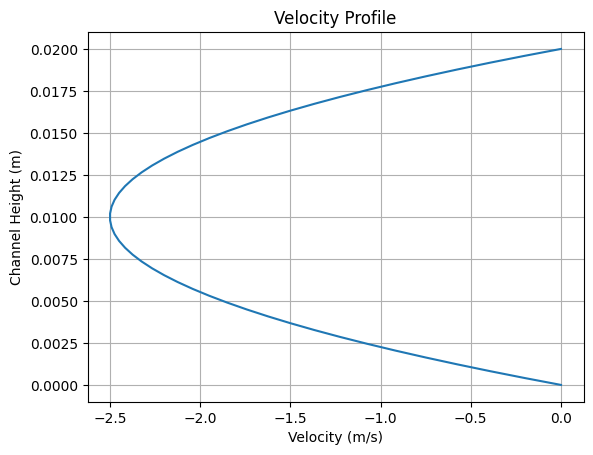

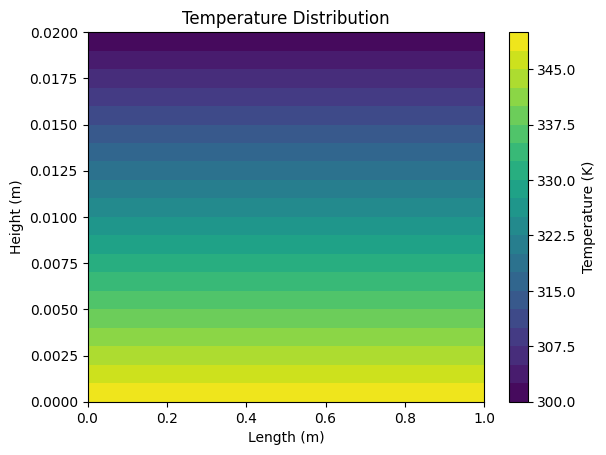

Maximum velocity: 2.4989587671803415 m/s
Wall temperature: 350 K


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Grid
nx = 50
ny = 50
L = 1.0      # Length (m)
H = 0.02     # Height (m)

dx = L / (nx - 1)
dy = H / (ny - 1)

x = np.linspace(0, L, nx)
y = np.linspace(0, H, ny)

# Physical parameters
mu = 1e-3     # Dynamic viscosity (Pa.s)
rho = 1000    # Density (kg/m3)
nu = mu / rho

alpha = 1.4e-7   # Thermal diffusivity (m2/s)
Tw = 350         # Wall temperature (K)
Tin = 300        # Inlet temperature (K)

# Pressure gradient (drives flow)
dpdx = -50   # Pa/m

# Velocity field
u = np.zeros((ny, nx))

# Solve velocity profile
for j in range(1, ny - 1):
    u[j, :] = (1/(2*mu)) * dpdx * (y[j] * (H - y[j]))

# Temperature field (simple linear assumption)
T = np.zeros((ny, nx))

for i in range(nx):
    for j in range(ny):
        T[j, i] = Tin + (Tw - Tin) * (1 - y[j] / H)

# Plot Velocity Profile
plt.figure()
plt.plot(u[:, 0], y)
plt.xlabel("Velocity (m/s)")
plt.ylabel("Channel Height (m)")
plt.title("Velocity Profile")
plt.grid()
plt.show()

# Plot Temperature Distribution
plt.figure()
plt.contourf(x, y, T, 20)
plt.colorbar(label="Temperature (K)")
plt.xlabel("Length (m)")
plt.ylabel("Height (m)")
plt.title("Temperature Distribution")
plt.show()

print("Maximum velocity:", np.max(np.abs(u)), "m/s")
print("Wall temperature:", Tw, "K")
